In [2]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [4]:
df = pd.read_csv("/content/train.csv" , usecols = ['Age','Fare','Survived'])

In [5]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [6]:
df.isnull().sum()

,0
Survived,0
Age,177
Fare,0


In [7]:
df['Age'].fillna(df['Age'].mean(),inplace = True)

/tmp/ipython-input-1652017284.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace = True)


In [8]:
df.isnull().sum()

,0
Survived,0
Age,0
Fare,0


In [9]:
df.head()


,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [11]:
x = df.iloc[:,1:3]
y = df.iloc[:,0]

In [12]:
X_train , X_test , y_train , y_test = train_test_split(x,y, test_size =0.2 , random_state=42)

/tmp/ipython-input-3055495847.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


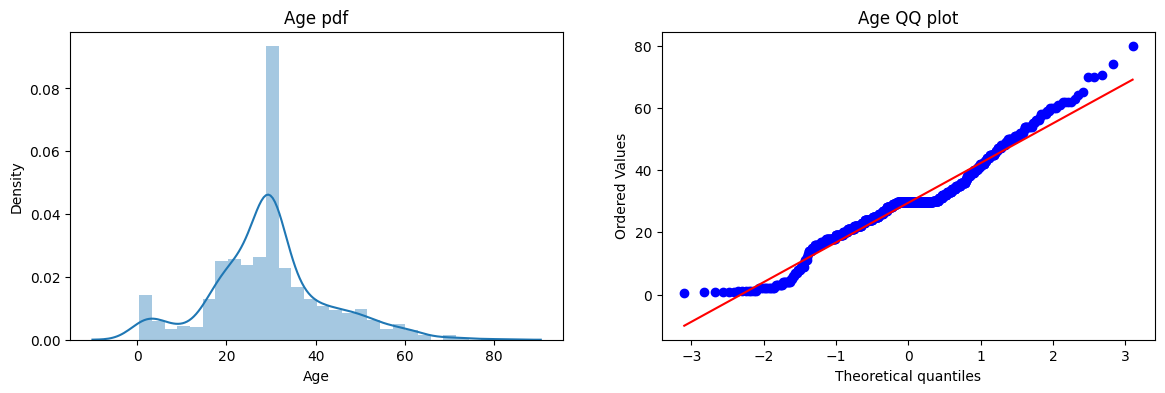

In [15]:
plt.figure(figsize = (14,4))
plt.subplot(121)
sns.distplot(X_train['Age'])
plt.title('Age pdf')

plt.subplot(122)
stats.probplot(X_train['Age'] , dist = "norm" , plot = plt)
plt.title('Age QQ plot')

plt.show()

/tmp/ipython-input-25625057.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


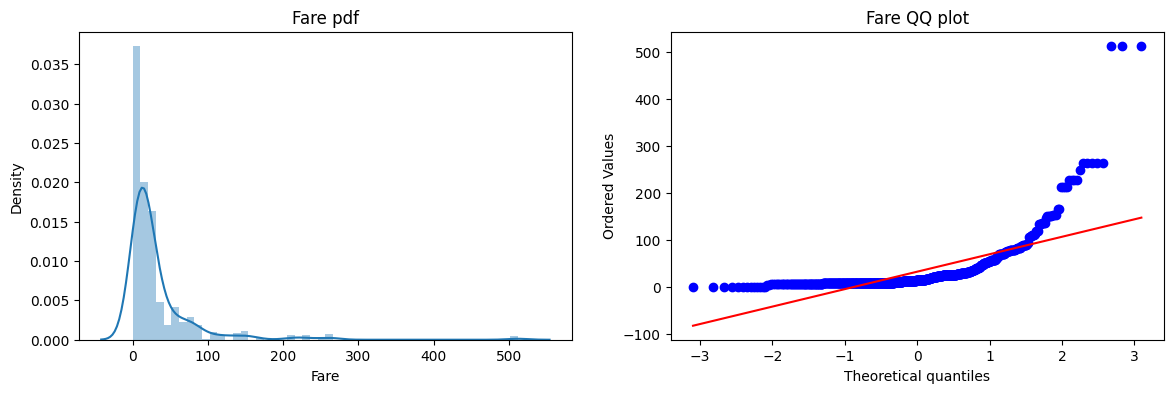

In [16]:
plt.figure(figsize = (14,4))
plt.subplot(121)
sns.distplot(X_train['Fare'])
plt.title('Fare pdf')

plt.subplot(122)
stats.probplot(X_train['Fare'] , dist = "norm" , plot = plt)
plt.title('Fare QQ plot')

plt.show()

In [18]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [19]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)
y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)

print("Accuracy LR" , accuracy_score(y_test , y_pred))
print("Accuracy DT" , accuracy_score(y_test, y_pred1))

Accuracy LR 0.6480446927374302
Accuracy DT 0.6536312849162011


In [21]:
#APPLYING LOG TRANSFORM
trf = FunctionTransformer(func = np.log1p)
#there exist a function np.log as well - but the main diff between np.log and np.log1p ids that
#np.log1p applied to to every value it is applied on so that no value is 0

In [22]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [24]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed , y_train)
clf2.fit(X_train_transformed , y_train)

y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)

print("Accuracy LR" , accuracy_score(y_test , y_pred))
print("Accuracy DT" , accuracy_score(y_test, y_pred1))

Accuracy LR 0.6815642458100558
Accuracy DT 0.6871508379888268


In [26]:
X_transformed = trf.fit_transform(x)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print('LR',np.mean(cross_val_score(clf , X_transformed , y , scoring="accuracy" , cv =10)))
print('DT',np.mean(cross_val_score(clf2 , X_transformed , y , scoring="accuracy" , cv =10)))

LR 0.678027465667915
DT 0.6566167290886393


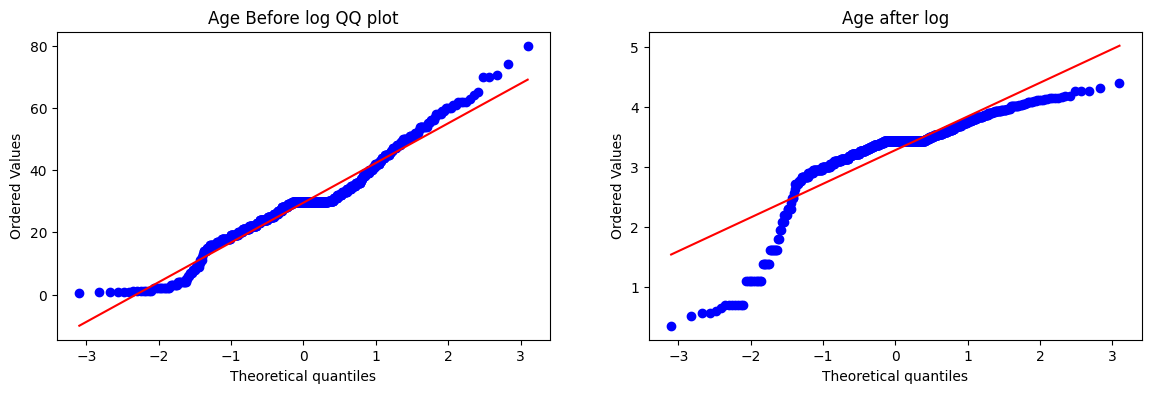

In [28]:
plt.figure(figsize = (14,4))
plt.subplot(121)
stats.probplot(X_train['Age'] , dist = "norm" , plot = plt)
plt.title('Age Before log QQ plot')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'] , dist = "norm" , plot = plt)
plt.title("Age after log")

plt.show()

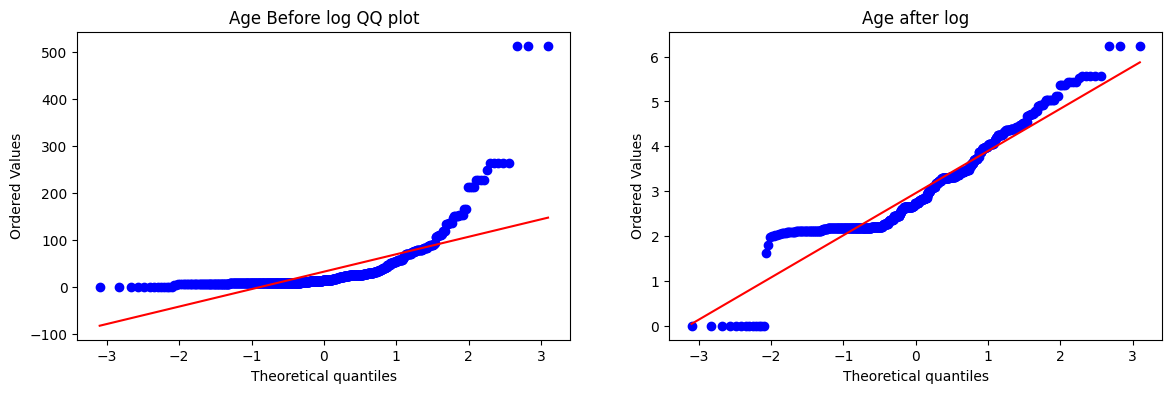

In [29]:
plt.figure(figsize = (14,4))
plt.subplot(121)
stats.probplot(X_train['Fare'] , dist = "norm" , plot = plt)
plt.title('Age Before log QQ plot')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'] , dist = "norm" , plot = plt)
plt.title("Age after log")

plt.show()
#this is right skewed and thus the result is much better

In [ ]:
#OBSERVATIONS
#1. Since Age was nearly normally distributed , there was not much diff to its QQ graph after the application of kog transform , it more or less made it worse
#2. Since the Graph of fare was right skewed the log transform was able tpo distribute it normally , thus its QQ graph became much better
#3. NOT MUCH DIFF on the decision tree classifier
#4. logistic reg had some changes to it as it does get affected by normally distributed data


In [35]:
#RECIPROCAL TRANSFORM
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]
    trf = ColumnTransformer([('log' , FunctionTransformer(transform),['Fare'])] , remainder = 'passthrough')
    X_trans = trf.fit_transform(x)
    clf = LogisticRegression()
    print("Accuracy" , np.mean(cross_val_score(clf,X_trans,y,scoring="accuracy" , cv = 10)))
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    stats.probplot(x['Fare'] , dist="norm" , plot = plt)
    plt.title("Fare after transform")
    plt.show()


Accuracy 0.6589013732833957


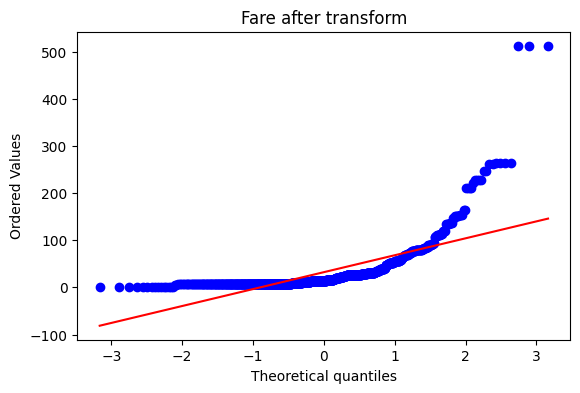

In [36]:
apply_transform(lambda x:x)

Accuracy 0.6431335830212235


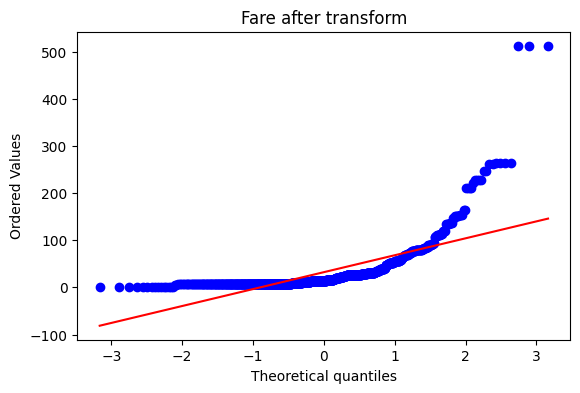

In [37]:
apply_transform(lambda x : x**2)

Accuracy 0.6589013732833957


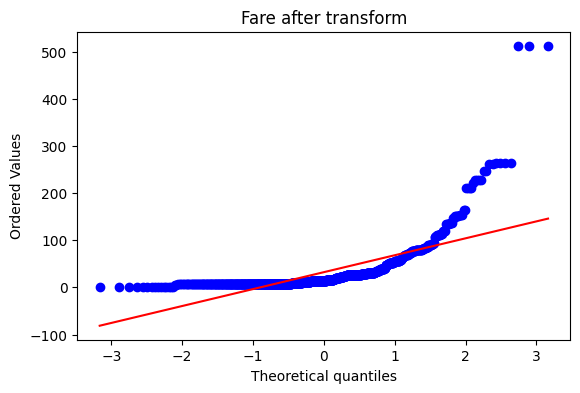

In [38]:
apply_transform(lambda x: x**1/2)

Accuracy 0.61729088639201


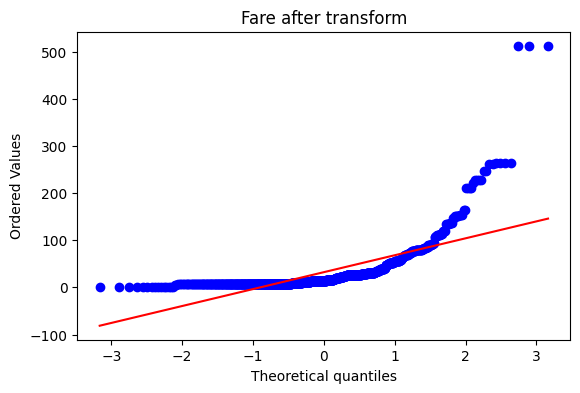

In [39]:
apply_transform(lambda x : 1/(x+0.001))

Accuracy 0.6195131086142323


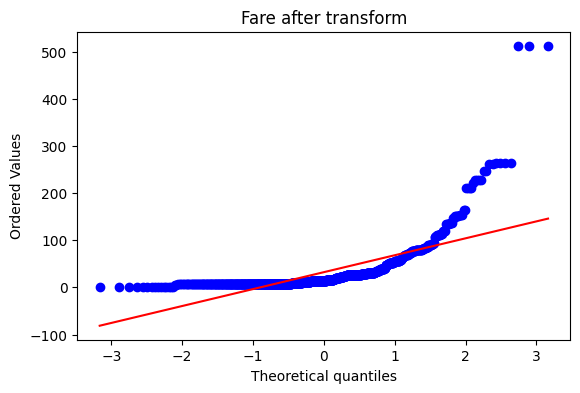

In [40]:
apply_transform(np.sin)